In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neural_network import MLPClassifier

from sklearn.datasets import make_classification

import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=42
)

columns = [
    "Rainfall",
    "River_Level",
    "Humidity",
    "Temperature",
    "Soil_Moisture",
    "Wind_Speed"
]

df = pd.DataFrame(X, columns=columns)
df["Flood"] = y

df.head()

,Rainfall,River_Level,Humidity,Temperature,Soil_Moisture,Wind_Speed,Flood
0,-0.223972,-2.366013,-0.488679,1.573681,0.911343,0.416648,1
1,0.777847,-1.123052,0.594504,-1.413674,2.340408,0.977132,1
2,-0.211784,1.278195,0.878723,0.195537,-2.025308,-0.640080,0
3,-0.073160,1.472937,0.761690,0.158895,-1.210951,-0.382450,1
4,0.026560,-1.457111,-0.052511,1.264830,0.448972,-0.453351,0


In [3]:
X = df.iloc[:, :-1]
y = df["Flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
ann = MLPClassifier(
    hidden_layer_sizes=(20,),
    max_iter=500,
    random_state=42
)

ann.fit(X_train, y_train)

prediction_ann = ann.predict(X_test)

accuracy_ann = accuracy_score(y_test, prediction_ann)

print("ANN Accuracy:", accuracy_ann)

ANN Accuracy: 0.9033333333333333


In [5]:
import random

population_size = 20
num_features = X_train.shape[1]
generations = 20

population = [
    np.random.randint(0,2,num_features)
    for i in range(population_size)
]

In [6]:
def fitness(chromosome):

    if chromosome.sum()==0:
        return 0

    selected = chromosome.astype(bool)

    X_train_new = X_train[:,selected]
    X_test_new = X_test[:,selected]

    model = MLPClassifier(
        hidden_layer_sizes=(20,),
        max_iter=300,
        random_state=42
    )

    model.fit(X_train_new,y_train)

    pred = model.predict(X_test_new)

    return accuracy_score(y_test,pred)

In [7]:
best_accuracy = 0

history=[]

for generation in range(generations):

    scores=[fitness(ch) for ch in population]

    best=np.argmax(scores)

    history.append(scores[best])

    if scores[best]>best_accuracy:
        best_accuracy=scores[best]
        best_chromosome=population[best]

    new_population=[]

    while len(new_population)<population_size:

        p1=random.choice(population)
        p2=random.choice(population)

        point=random.randint(1,num_features-1)

        child=np.concatenate((p1[:point],p2[point:]))

        mutation=random.randint(0,num_features-1)

        child[mutation]=1-child[mutation]

        new_population.append(child)

    population=new_population

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [8]:
print("Best Feature Selection:")
print(best_chromosome)

print("GA Best Accuracy:",best_accuracy)

Best Feature Selection:
[1 1 1 1 1 1]
GA Best Accuracy: 0.9166666666666666


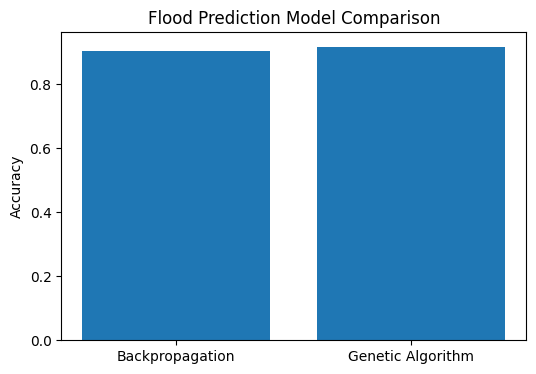

In [9]:
models=["Backpropagation","Genetic Algorithm"]

accuracy=[
    accuracy_ann,
    best_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(models,accuracy)

plt.ylabel("Accuracy")

plt.title("Flood Prediction Model Comparison")

plt.show()